# Clustering Lab

 
Based of the amazing work you did in the Movie Industry you've been recruited to the NBA! You are working as the VP of Analytics that helps support a head scout, Mr. Rooney, for the worst team in the NBA probably the Wizards. Mr. Rooney just heard about Data Science and thinks it can solve all the team's problems!!! He wants you to figure out a way to find players that are high performing but maybe not highly paid that you can steal to get the team to the playoffs! 

In this document you will work through a similar process that we did in class with the NBA data (NBA_Perf_22 and nba_salaries_22), merging them together.

Details: 

- Determine a way to use clustering to estimate based on performance if 
players are under or over paid, generally. 

- Then select players you believe would be best for your team and explain why. Do so in three categories: 
    * Examples that are not good choices (3 or 4) 
    * Several options that are good choices (3 or 4)
    * Several options that could work, assuming you can't get the players in the good category (3 or 4)

- You will decide the cutoffs for each category, so you should be able to explain why you chose them.

- Provide a well commented and clean report of your findings in a separate notebook that can be presented to Mr. Rooney, keeping in mind he doesn't understand...anything. Include a rationale for variables you included in the model, details on your approach and a overview of the results with supporting visualizations. 


Hints:

- Salary is the variable you are trying to understand 
- When interpreting you might want to use graphs that include variables that are the most correlated with Salary
- You'll need to scale the variables before performing the clustering
- Be specific about why you selected the players that you did, more detail is better
- Use good coding practices, comment heavily, indent, don't use for loops unless totally necessary and create modular sections that align with some outcome. If necessary create more than one script,list/load libraries at the top and don't include libraries that aren't used. 
- Be careful for non-traditional characters in the players names, certain graphs won't work when these characters are included.


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import sklearn as sk
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load salary data
salary_data = pd.read_csv('2025_salaries.csv', header=1) # CSV has column names on second row
salary_data.head()

,Player,Tm,2025-26
0,Jaden Springer,NOP,"$70,732"
1,Garrison Mathews,IND,"$131,970"
2,Garrison Mathews,IND,"$131,970"
3,Mac McClung,IND,"$164,060"
4,Didi Louzada,POR,"$268,032"


In [3]:
# Load player data
stats = pd.read_csv('nba_2025.txt', sep=',', encoding='latin-1')
stats.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional
0,1.0,Shai Gilgeous-Alexander,27.0,OKC,PG,49.0,49.0,1632.0,534.0,964.0,...,218.0,314.0,64.0,38.0,103.0,101.0,1558.0,0.0,NaN,gilgesh01
1,2.0,Tyrese Maxey,25.0,PHI,PG,52.0,52.0,2008.0,524.0,1117.0,...,214.0,351.0,102.0,40.0,126.0,118.0,1503.0,0.0,NaN,maxeyty01
2,3.0,Donovan Mitchell,29.0,CLE,SG,51.0,51.0,1719.0,516.0,1060.0,...,229.0,302.0,79.0,15.0,159.0,125.0,1478.0,0.0,NaN,mitchdo01
3,4.0,Jaylen Brown,29.0,BOS,SF,49.0,49.0,1676.0,534.0,1105.0,...,336.0,229.0,49.0,20.0,176.0,136.0,1435.0,2.0,NaN,brownja02
4,5.0,Luka DonÄiÄ,26.0,LAL,PG,42.0,42.0,1492.0,437.0,923.0,...,329.0,360.0,61.0,19.0,179.0,102.0,1379.0,6.0,NaN,doncilu01


In [4]:
# Merge Datasets
merged_data = pd.merge(salary_data, stats, on='Player')
merged_data.head()

,Player,Tm,2025-26,Rk,Age,Team,Pos,G,GS,MP,...,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional
0,Garrison Mathews,IND,"$131,970",398.0,29.0,IND,SG,15.0,1.0,196.0,...,17.0,10.0,6.0,3.0,3.0,19.0,78.0,0.0,NaN,mathega01
1,Garrison Mathews,IND,"$131,970",398.0,29.0,IND,SG,15.0,1.0,196.0,...,17.0,10.0,6.0,3.0,3.0,19.0,78.0,0.0,NaN,mathega01
2,Mac McClung,IND,"$164,060",459.0,27.0,2TM,SG,4.0,0.0,47.0,...,5.0,2.0,5.0,2.0,3.0,8.0,23.0,0.0,NaN,mccluma01
3,Mac McClung,IND,"$164,060",459.0,27.0,IND,SG,3.0,0.0,34.0,...,4.0,1.0,5.0,1.0,2.0,6.0,19.0,0.0,NaN,mccluma01
4,Mac McClung,IND,"$164,060",459.0,27.0,CHI,SG,1.0,0.0,13.0,...,1.0,1.0,0.0,1.0,1.0,2.0,4.0,0.0,NaN,mccluma01


In [5]:
# Looks like team column shows up twice, let's drop the one from the salary dataset
merged_data = merged_data.drop('Tm',axis=1)

In [6]:
# Dealing with duplicates:
# Looks like if a player got traded in the middle of the season,
# They have 3 rows of data: Combined (2TM), and one row for their performance
# On each team
# This applies to everyone except the first two rows, where Garrison Matthews
# Just has a duplicated row
# Let's drop the duplicated row, and only take into account the combined stats.
# It doesn't make sense to look at a player's performance on only one team, we want
# to see how they have been playing all year, regardless of team. This way we do not remove
# any data.

# make list of traded/duplicate players
traded_players = merged_data.loc[merged_data['Team'] == '2TM', 'Player']
merged_data = merged_data[
    (merged_data['Team']== '2TM') | 
    (~merged_data['Player'].isin(traded_players))
]
merged_data.head()


,Player,2025-26,Rk,Age,Team,Pos,G,GS,MP,FG,...,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional
0,Garrison Mathews,"$131,970",398.0,29.0,IND,SG,15.0,1.0,196.0,21.0,...,17.0,10.0,6.0,3.0,3.0,19.0,78.0,0.0,NaN,mathega01
1,Garrison Mathews,"$131,970",398.0,29.0,IND,SG,15.0,1.0,196.0,21.0,...,17.0,10.0,6.0,3.0,3.0,19.0,78.0,0.0,NaN,mathega01
2,Mac McClung,"$164,060",459.0,27.0,2TM,SG,4.0,0.0,47.0,9.0,...,5.0,2.0,5.0,2.0,3.0,8.0,23.0,0.0,NaN,mccluma01
5,Monte Morris,"$321,184",470.0,30.0,IND,PG,6.0,0.0,65.0,7.0,...,7.0,9.0,1.0,1.0,2.0,3.0,18.0,0.0,NaN,morrimo01
6,E.J. Liddell,"$706,898",461.0,25.0,BRK,PF,10.0,0.0,49.0,8.0,...,11.0,0.0,1.0,0.0,0.0,4.0,22.0,0.0,NaN,liddeej01


In [7]:
# Now for traded players, only their combined stats will show up.
# Let's drop the duplicated Garrison Matthews row

merged_data = merged_data.drop_duplicates()
merged_data.head()

,Player,2025-26,Rk,Age,Team,Pos,G,GS,MP,FG,...,TRB,AST,STL,BLK,TOV,PF,PTS,Trp-Dbl,Awards,Player-additional
0,Garrison Mathews,"$131,970",398.0,29.0,IND,SG,15.0,1.0,196.0,21.0,...,17.0,10.0,6.0,3.0,3.0,19.0,78.0,0.0,NaN,mathega01
2,Mac McClung,"$164,060",459.0,27.0,2TM,SG,4.0,0.0,47.0,9.0,...,5.0,2.0,5.0,2.0,3.0,8.0,23.0,0.0,NaN,mccluma01
5,Monte Morris,"$321,184",470.0,30.0,IND,PG,6.0,0.0,65.0,7.0,...,7.0,9.0,1.0,1.0,2.0,3.0,18.0,0.0,NaN,morrimo01
6,E.J. Liddell,"$706,898",461.0,25.0,BRK,PF,10.0,0.0,49.0,8.0,...,11.0,0.0,1.0,0.0,0.0,4.0,22.0,0.0,NaN,liddeej01
7,James Wiseman,"$1,000,000",480.0,24.0,IND,C,4.0,1.0,58.0,6.0,...,8.0,3.0,0.0,1.0,5.0,10.0,13.0,0.0,NaN,wisemja01


In [8]:
#Drop variables that will not be needed or are duplicates
#Look at merged_data variables:
#merged_data.info()
# choose the features we want to take into account:
features = ['PTS', 'TRB', 'STL', 'BLK', 'AST']
X = merged_data[features]
X.head()

,PTS,TRB,STL,BLK,AST
0,78.0,17.0,6.0,3.0,10.0
2,23.0,5.0,5.0,2.0,2.0
5,18.0,7.0,1.0,1.0,9.0
6,22.0,11.0,1.0,0.0,0.0
7,13.0,8.0,0.0,1.0,3.0


In [9]:
# scale X
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
#Run the clustering algo with your best guess for K
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [11]:
# View the results
print(kmeans.cluster_centers_)
print(kmeans.labels_)

[[-0.90083335 -0.89559535 -0.96517894 -0.66393914 -0.77434225]
 [ 1.38233685  0.69658372  1.31750178  0.11560363  1.56495682]
 [ 0.70446719  1.76580095  0.42469834  2.34091076  0.13066994]
 [ 0.0090271   0.08227874  0.18501331 -0.00350665 -0.06449449]]
[0 0 0 0 0 0 0 0 0 3 0 0 0 0 3 0 0 3 3 0 0 0 0 3 0 0 3 0 0 3 1 0 0 0 0 0 3
 0 3 0 3 0 0 3 0 0 3 0 0 0 3 3 0 0 1 0 2 3 0 0 0 0 3 3 3 3 3 0 0 0 3 0 0 0
 3 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 2 3 3 3 3 2 3 2 1 3 0 1 0 0 3 3 1 0 3 1 0
 3 0 0 3 0 0 0 0 3 3 3 0 0 0 0 1 0 3 1 3 3 0 3 3 0 0 0 2 0 3 3 3 3 0 0 3 0
 3 1 0 3 0 1 3 0 1 0 0 0 0 1 3 2 0 2 3 0 1 0 0 0 0 0 0 3 0 0 3 1 2 0 3 0 1
 0 2 0 0 3 3 3 0 3 3 1 0 3 0 0 0 1 0 3 3 3 2 3 0 2 0 3 3 3 0 3 0 3 0 0 0 2
 1 3 3 1 3 1 3 0 1 0 1 0 0 3 3 3 3 1 3 0 3 3 3 1 0 3 1 3 3 0 3 0 1 3 1 3 0
 1 3 3 3 1 3 3 3 1 0 3 2 0 3 3 2 3 1 3 0 0 3 3 1 2 3 1 2 3 3 0 0 3 2 3 2 2
 0 3 0 0 2 1 3 3 0 0 3 3 3 2 1 2 2 0 2 1 1 3 3 3 3 3 3 3 3 0 1 2 3 3 3 3 3
 3 3 1 0 2 1 3 1 2 3 3 0 3 3 2 1 1 1 1 1 2 2 1 2 3 3 3 3 3 3 2 2 3 1 1 1

In [12]:
#Create a visualization of the results with 2 or 3 variables that you think will best
#differentiate the clusters

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

merged_data['cluster'] = kmeans.labels_

fig = px.scatter_3d(
    merged_data, x="PTS", y="AST", z="TRB",
    color=kmeans.labels_,
)
fig.show(renderer="browser")



In [13]:
# Looks like PTS vs. TRB shows the clusters the best. 
# Cluster 0 looks to be low performing players, cluster 3
# mediocre players, and clusters 1 and 2 are our high performers,
# with cluster 1 being higher scorers and cluster 2 being
# better rebounders/defenders.

In [14]:
#Evaluate the quality of the clustering using total variance explained and silhouette scores
from sklearn.metrics import silhouette_score

print(kmeans.inertia_)
print(silhouette_score(X_scaled, merged_data['cluster']))

# It's hard to evaluate our inertia score without looking at other values of k first,
# but our silhoutte score of .37 indicates that the clusters are pretty distinguishable, but 
# there is some overlap between them.

658.4585625875851
0.36937693199687005


In [15]:
#Determine the ideal number of clusters using the elbow method and the silhouette coefficient
k_values = range(2, 10) 
inertias = []
sil_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    labels = kmeans.labels_
    
    # store inertia
    inertias.append(kmeans.inertia_)
    
    # store silhouette score
    sil_scores.append(silhouette_score(X_scaled, labels))


for k, inertia, sil in zip(k_values, inertias, sil_scores):
    print(k, inertia, sil)

2 1127.8986813371341 0.4285444971068608
3 881.8940072750518 0.4299497993758842
4 658.4585625875851 0.36937693199687005
5 598.3767069092892 0.3461342249727311
6 534.724885228122 0.3352625012338703
7 501.421266567715 0.31705599296754283
8 463.71618993754754 0.27872940797269774
9 439.08452898016407 0.27943880057187237


In [16]:
# Examining the results, it looks like the elbow occurs at around
# k=4-6. k=4 seems to be the elbow, as it doesn't decrease as rapidly after
# 4. It also has a moderate silhoutte score.

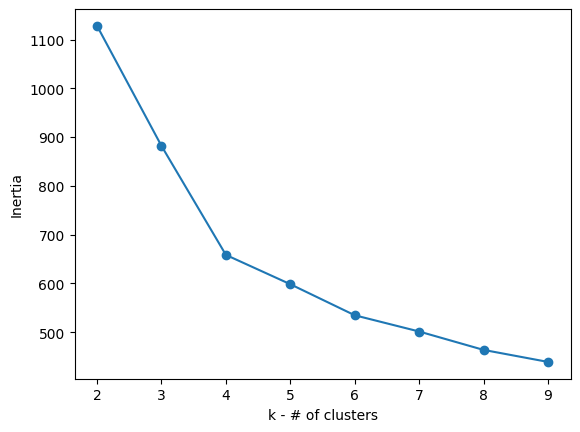

In [17]:
#Visualize the results of the elbow method
plt.plot(k_values,inertias,marker='o')
plt.xlabel('k - # of clusters')
plt.ylabel('Inertia')
plt.show()

In [18]:
#Use the recommended number of cluster (assuming it's different) to retrain your model and visualize the results
#Recommended number is the same as before
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

print(kmeans.cluster_centers_)
print(kmeans.labels_)

[[-0.90083335 -0.89559535 -0.96517894 -0.66393914 -0.77434225]
 [ 1.38233685  0.69658372  1.31750178  0.11560363  1.56495682]
 [ 0.70446719  1.76580095  0.42469834  2.34091076  0.13066994]
 [ 0.0090271   0.08227874  0.18501331 -0.00350665 -0.06449449]]
[0 0 0 0 0 0 0 0 0 3 0 0 0 0 3 0 0 3 3 0 0 0 0 3 0 0 3 0 0 3 1 0 0 0 0 0 3
 0 3 0 3 0 0 3 0 0 3 0 0 0 3 3 0 0 1 0 2 3 0 0 0 0 3 3 3 3 3 0 0 0 3 0 0 0
 3 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 2 3 3 3 3 2 3 2 1 3 0 1 0 0 3 3 1 0 3 1 0
 3 0 0 3 0 0 0 0 3 3 3 0 0 0 0 1 0 3 1 3 3 0 3 3 0 0 0 2 0 3 3 3 3 0 0 3 0
 3 1 0 3 0 1 3 0 1 0 0 0 0 1 3 2 0 2 3 0 1 0 0 0 0 0 0 3 0 0 3 1 2 0 3 0 1
 0 2 0 0 3 3 3 0 3 3 1 0 3 0 0 0 1 0 3 3 3 2 3 0 2 0 3 3 3 0 3 0 3 0 0 0 2
 1 3 3 1 3 1 3 0 1 0 1 0 0 3 3 3 3 1 3 0 3 3 3 1 0 3 1 3 3 0 3 0 1 3 1 3 0
 1 3 3 3 1 3 3 3 1 0 3 2 0 3 3 2 3 1 3 0 0 3 3 1 2 3 1 2 3 3 0 0 3 2 3 2 2
 0 3 0 0 2 1 3 3 0 0 3 3 3 2 1 2 2 0 2 1 1 3 3 3 3 3 3 3 3 0 1 2 3 3 3 3 3
 3 3 1 0 2 1 3 1 2 3 3 0 3 3 2 1 1 1 1 1 2 2 1 2 3 3 3 3 3 3 2 2 3 1 1 1

In [19]:
# Once again evaluate the quality of the clustering using total variance explained and silhouette scores
# Same as before

In [23]:
#Use the model to select players for Mr. Rooney to consider
#Let's plot PTS vs TRB, and shade by salary
# First, in order to shade by salary, we must change the values for that column
# to integers. This means we have to remove the dollar signs/commas.
merged_data['2025-26'] = (
    merged_data['2025-26']
    .astype(str)
    .str.replace('[$,]', '', regex=True)
    .astype(float)
)
fig = px.scatter(
    merged_data,
    x='TRB',
    y='PTS',
    color='2025-26',   # salary gradient
    symbol='cluster',
    hover_data=['Player', 'Team', '2025-26']  # what shows on hover
)
fig.update_layout(
    legend=dict(
        x=1.15,   # move right
        y=1
    )
)
fig.update_layout(
    width=900,
    height=500
)
fig.show()
fig.write_html('plot.html')

**Disclaimer**: An interactive version of this visualization is available in the file plot.html. Please download and open it in a web browser to explore the data.

In [21]:
# With this, 
# Cluster 0: low performing players
# Cluster 3: Mid-level contributors
# Cluster 2: High-rebounding/defensive players
# Cluster 1: High scoring players, elite production overall

# Choosing expensive vs. cheap players:
# NBA salaries are highly skewed, with a small number of players 
# earning significantly higher salaries than the rest. 
# Because of this, percentile-based thresholds did not clearly capture the 
# highest-paid players. Instead, I defined salary tiers based on meaningful cutoffs 
# in the data distribution. Players earning $40 million or more were classified as expensive, 
# as this represents top-tier contracts, while players earning $15 million or less were considered relatively inexpensive.

# Examples that are not good choices (3 or 4) 
# These are players that are considered expensive and low/mid-performing.
# Paul George, Bradley Beal, Anthony Davis

# Several options that are good choices (3 or 4)
# These are players in clusters 1 or 2, that are considered cheap.
# Let's try to get 2 from cluster 1 and 2 from cluster 2.
# Donovan Clingan, Jalen Duren, Keyonte George, Deni Avdija

# Several options that could work, assuming you can't get the players in the good category (3 or 4)
# These are players that are in cluster 3 and are considered cheap. 
# Julian Champagnie, Jaylon Tyson, Sandro Mamukelashvili

In [22]:
#Write up the results in a separate notebook with supporting visualizations and 
# an overview of how and why you made the choices you did. This should be at least 
# 500 words and should be written for a non-technical audience.